In [1]:
!pip install kagglehub

In [2]:
import kagglehub
import pandas as pd
import os

pd.set_option('display.max_columns', None)

# Download dataset
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

print("Path dataset:", path)

# List contents of the downloaded directory to verify its structure
print("Contents of downloaded directory:", os.listdir(path))

# Load the single dataset file
df = pd.read_csv(os.path.join(path, "heart.csv"))

display(df.info())

Using Colab cache for faster access to the 'heart-failure-prediction' dataset.
Path dataset: /kaggle/input/heart-failure-prediction
Contents of downloaded directory: ['heart.csv']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


None

# **1. Mendeskripsikan Data**

In [3]:
# Numeric features
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [4]:
# Categorical features
df.describe(include=['object'])

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
count,918,918,918,918,918
unique,2,4,3,2,3
top,M,ASY,Normal,N,Flat
freq,725,496,552,547,460


In [5]:
# Count missing values
df.isnull().sum().to_frame().T

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,0,0,0,0,0,0,0,0,0,0,0,0


In [6]:
# Unique values per column
df.nunique().to_frame().T

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,50,2,4,67,222,2,3,119,2,53,3,2


# **2. Eksplorasi Data**
- Distribusi
- Korelasi
- Pasangan

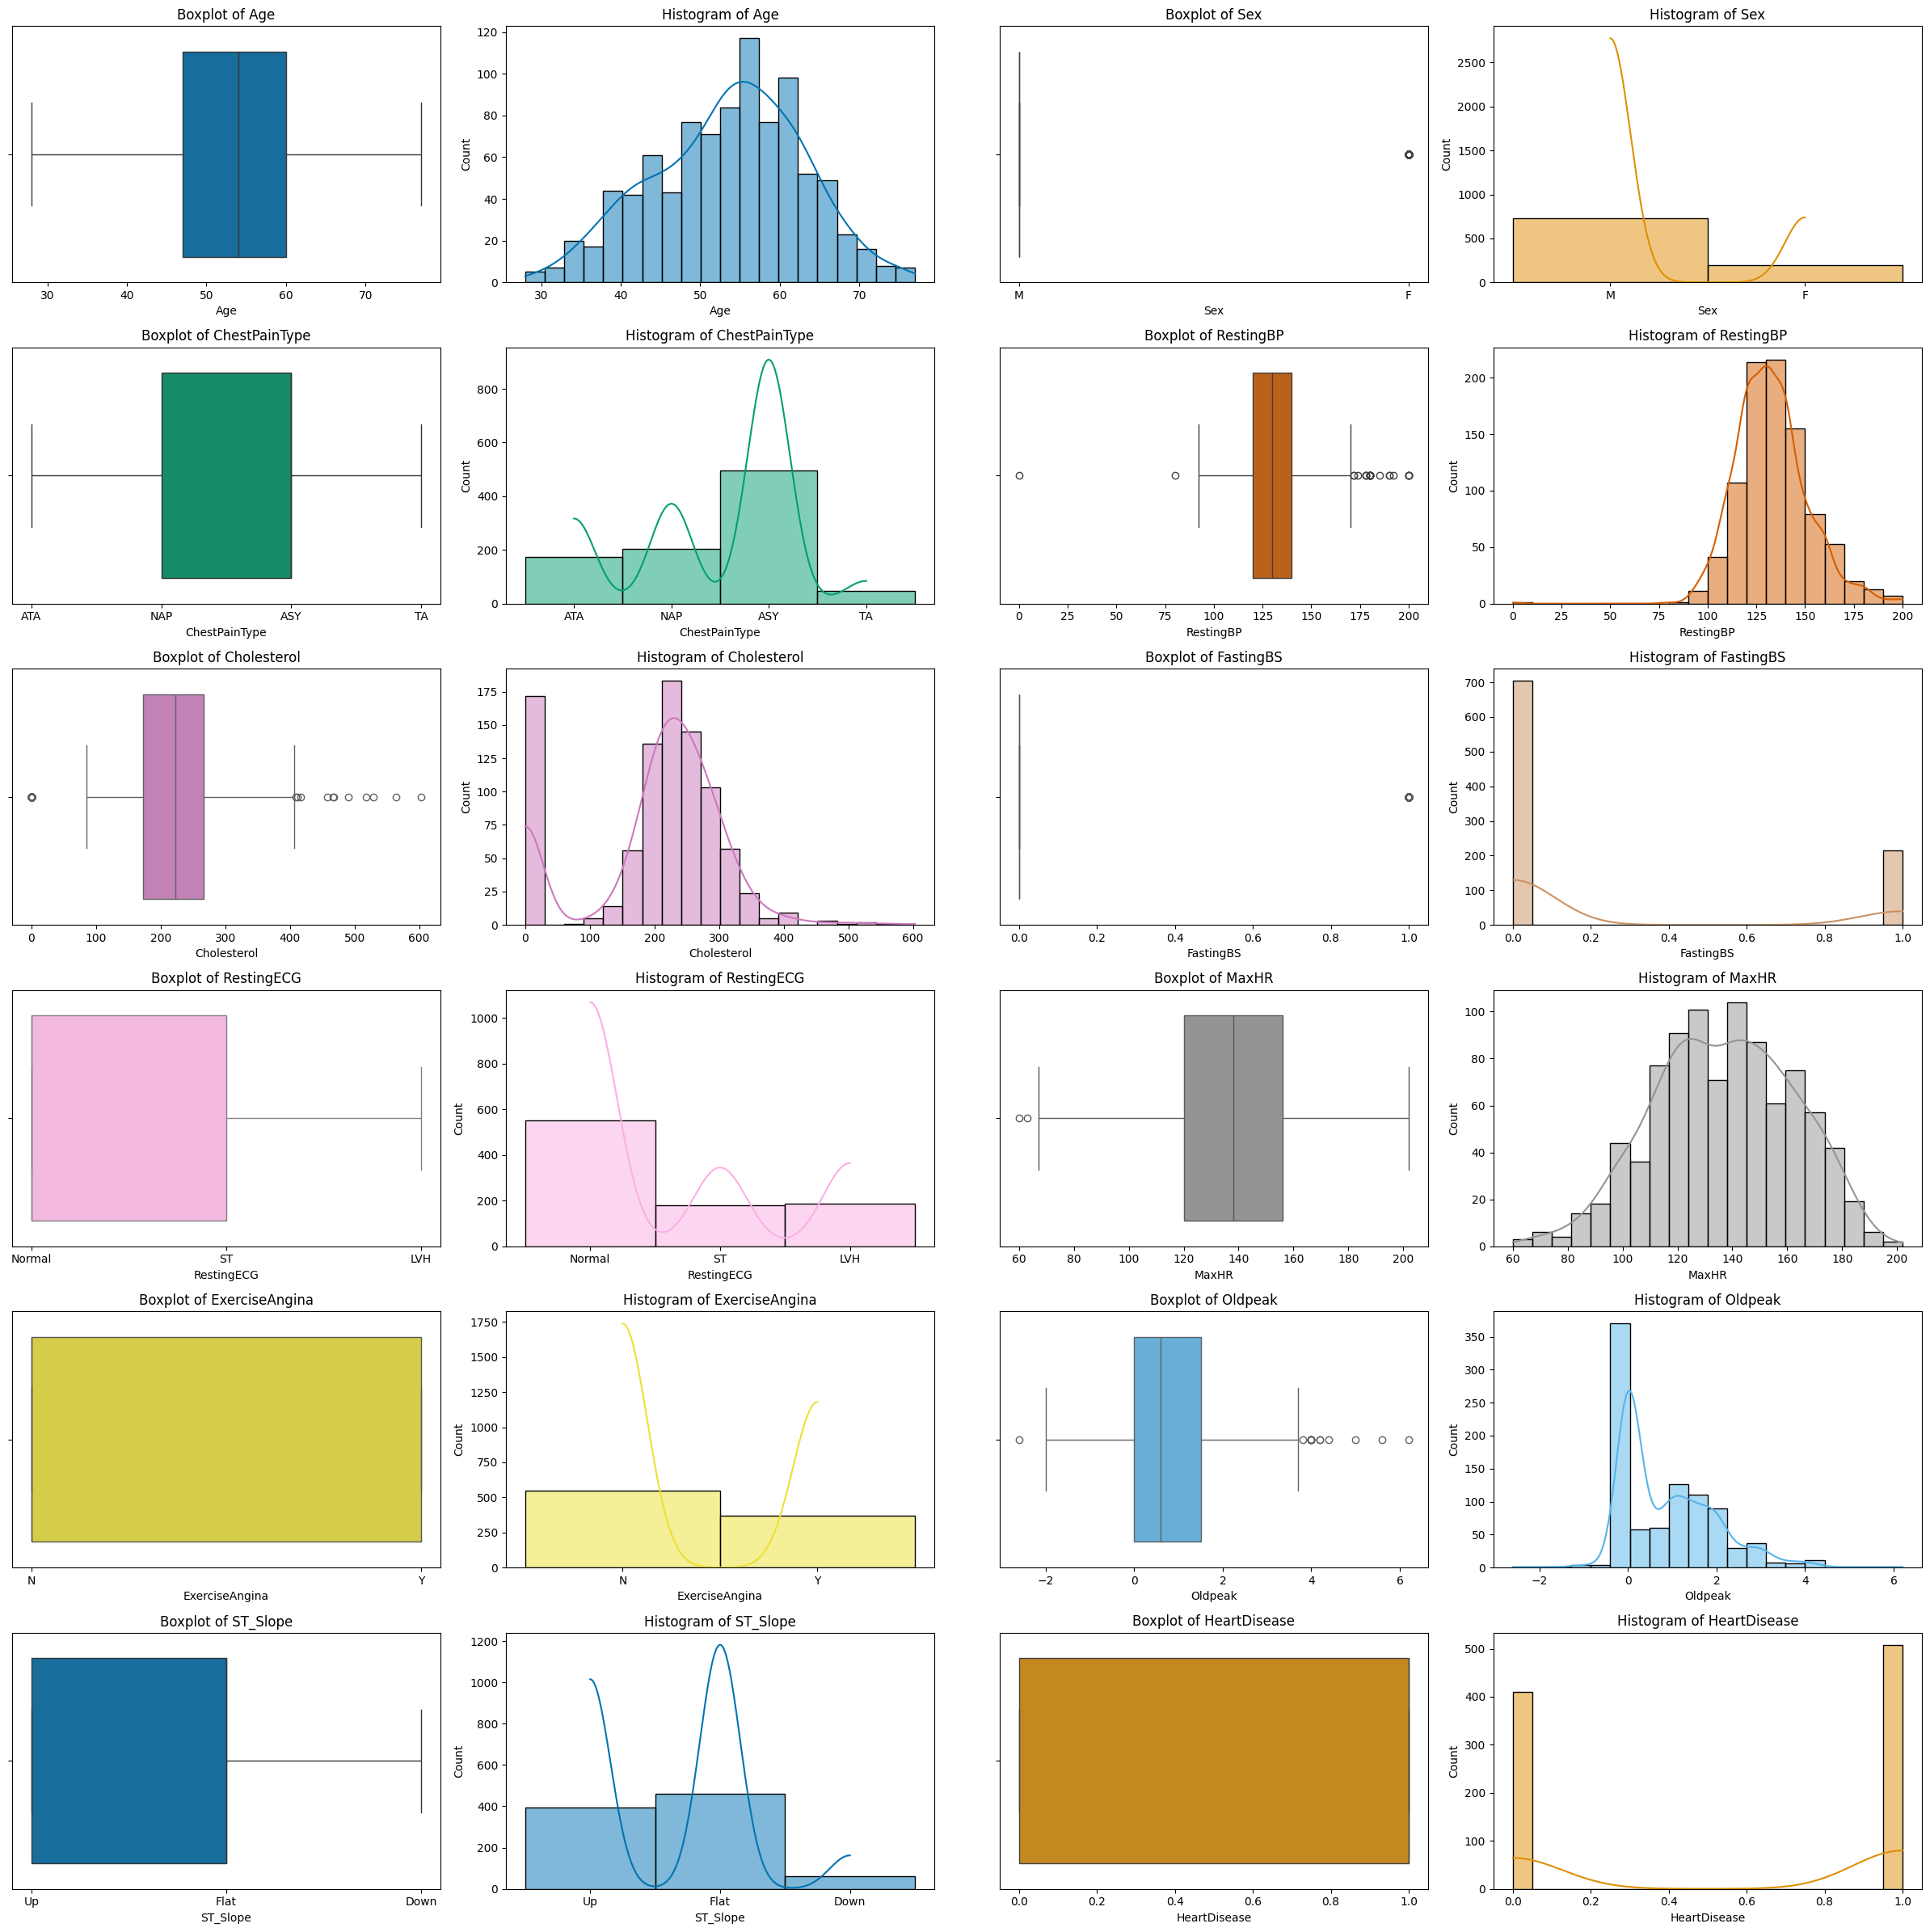

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select numeric columns
num_cols = df.select_dtypes(include=['int32', 'int64', 'float64', 'object']).columns

# Assign color palette
colors = sns.color_palette('colorblind', n_colors=len(num_cols))

# Each feature uses 2 columns (box + hist) → total cols = 4
ncols = 4
nrows = (len(num_cols) * 2 + ncols - 1) // ncols  # round up

fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
axes = axes.flatten()

plot_idx = 0
for col, color in zip(num_cols, colors):
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[plot_idx], color=color)
    axes[plot_idx].set_title(f'Boxplot of {col}')
    plot_idx += 1

    # Histogram
    sns.histplot(df[col], bins=20, kde=True, ax=axes[plot_idx], color=color)
    axes[plot_idx].set_title(f'Histogram of {col}')
    plot_idx += 1

# Remove unused axes
for j in range(plot_idx, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [8]:
from sklearn.preprocessing import LabelEncoder

def encode_object_columns(df):
    """
    Encode all object-type columns in a DataFrame to integers.
    Returns a new DataFrame with encoded columns and a dictionary of encoders.
    """
    df_encoded = df.copy()  # don't override original
    le_dict = {}

    obj_cols = df_encoded.select_dtypes(include='object').columns
    for col in obj_cols:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])
        le_dict[col] = le  # save encoder for inverse transform

    return df_encoded, le_dict

In [9]:
df_encoded, encoders = encode_object_columns(df)

display(df_encoded.head(5))

for col, encoder in encoders.items():
    print(f"Encoder for column '{col}': {encoder.classes_}")

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,1,108,1,1.5,1,1
4,54,1,2,150,195,0,1,122,0,0.0,2,0


Encoder for column 'Sex': ['F' 'M']
Encoder for column 'ChestPainType': ['ASY' 'ATA' 'NAP' 'TA']
Encoder for column 'RestingECG': ['LVH' 'Normal' 'ST']
Encoder for column 'ExerciseAngina': ['N' 'Y']
Encoder for column 'ST_Slope': ['Down' 'Flat' 'Up']


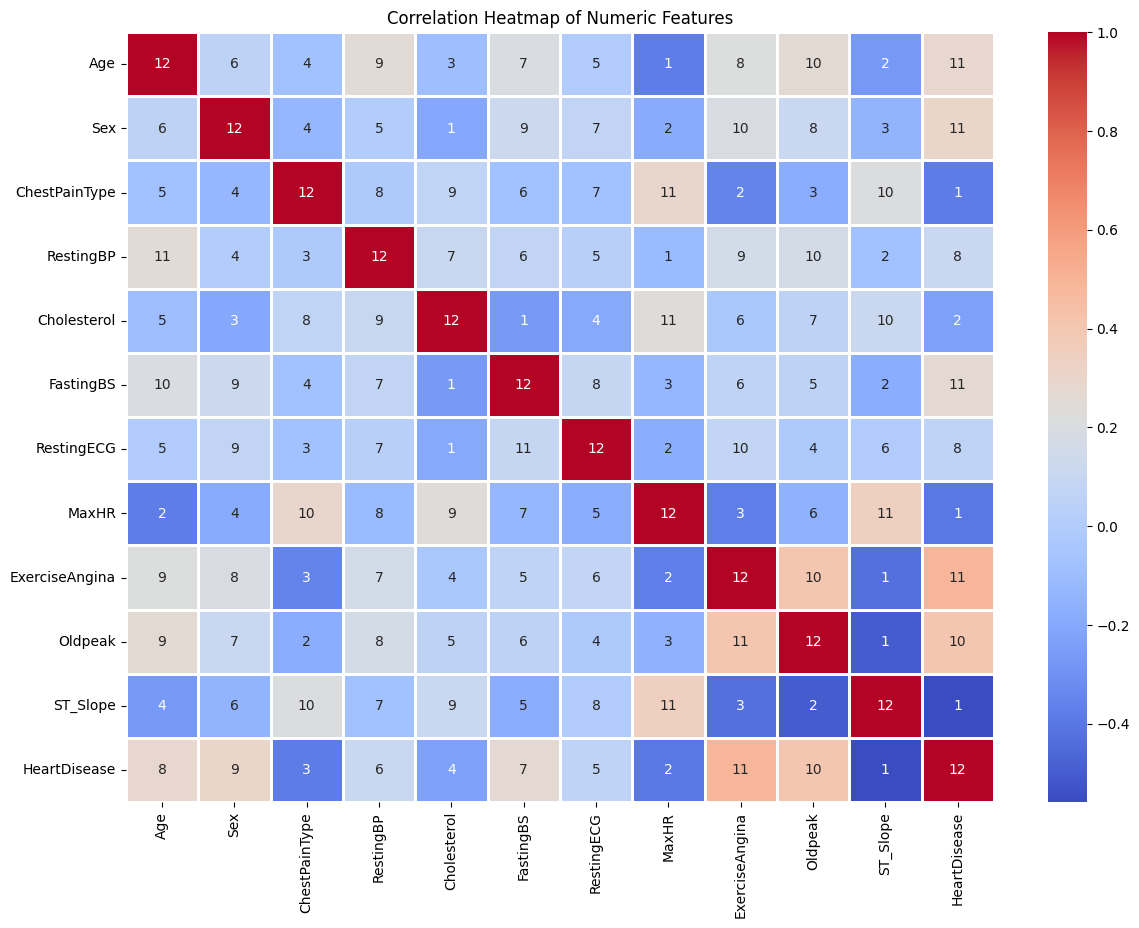

In [10]:
plt.figure(figsize=(14,10))
corr = df_encoded.select_dtypes(include=['float64','int64','int32']).corr()
sns.heatmap(corr, annot=corr.rank(axis='columns'), linewidth=1, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

Top correlated feature pairs:
 ExerciseAngina  HeartDisease    0.494282
                Oldpeak         0.408752
Oldpeak         HeartDisease    0.403951
MaxHR           ST_Slope        0.343419
Sex             HeartDisease    0.305445
dtype: float64
Selected features for pairplot: ['Sex', 'ST_Slope', 'Oldpeak', 'ExerciseAngina', 'MaxHR', 'HeartDisease']


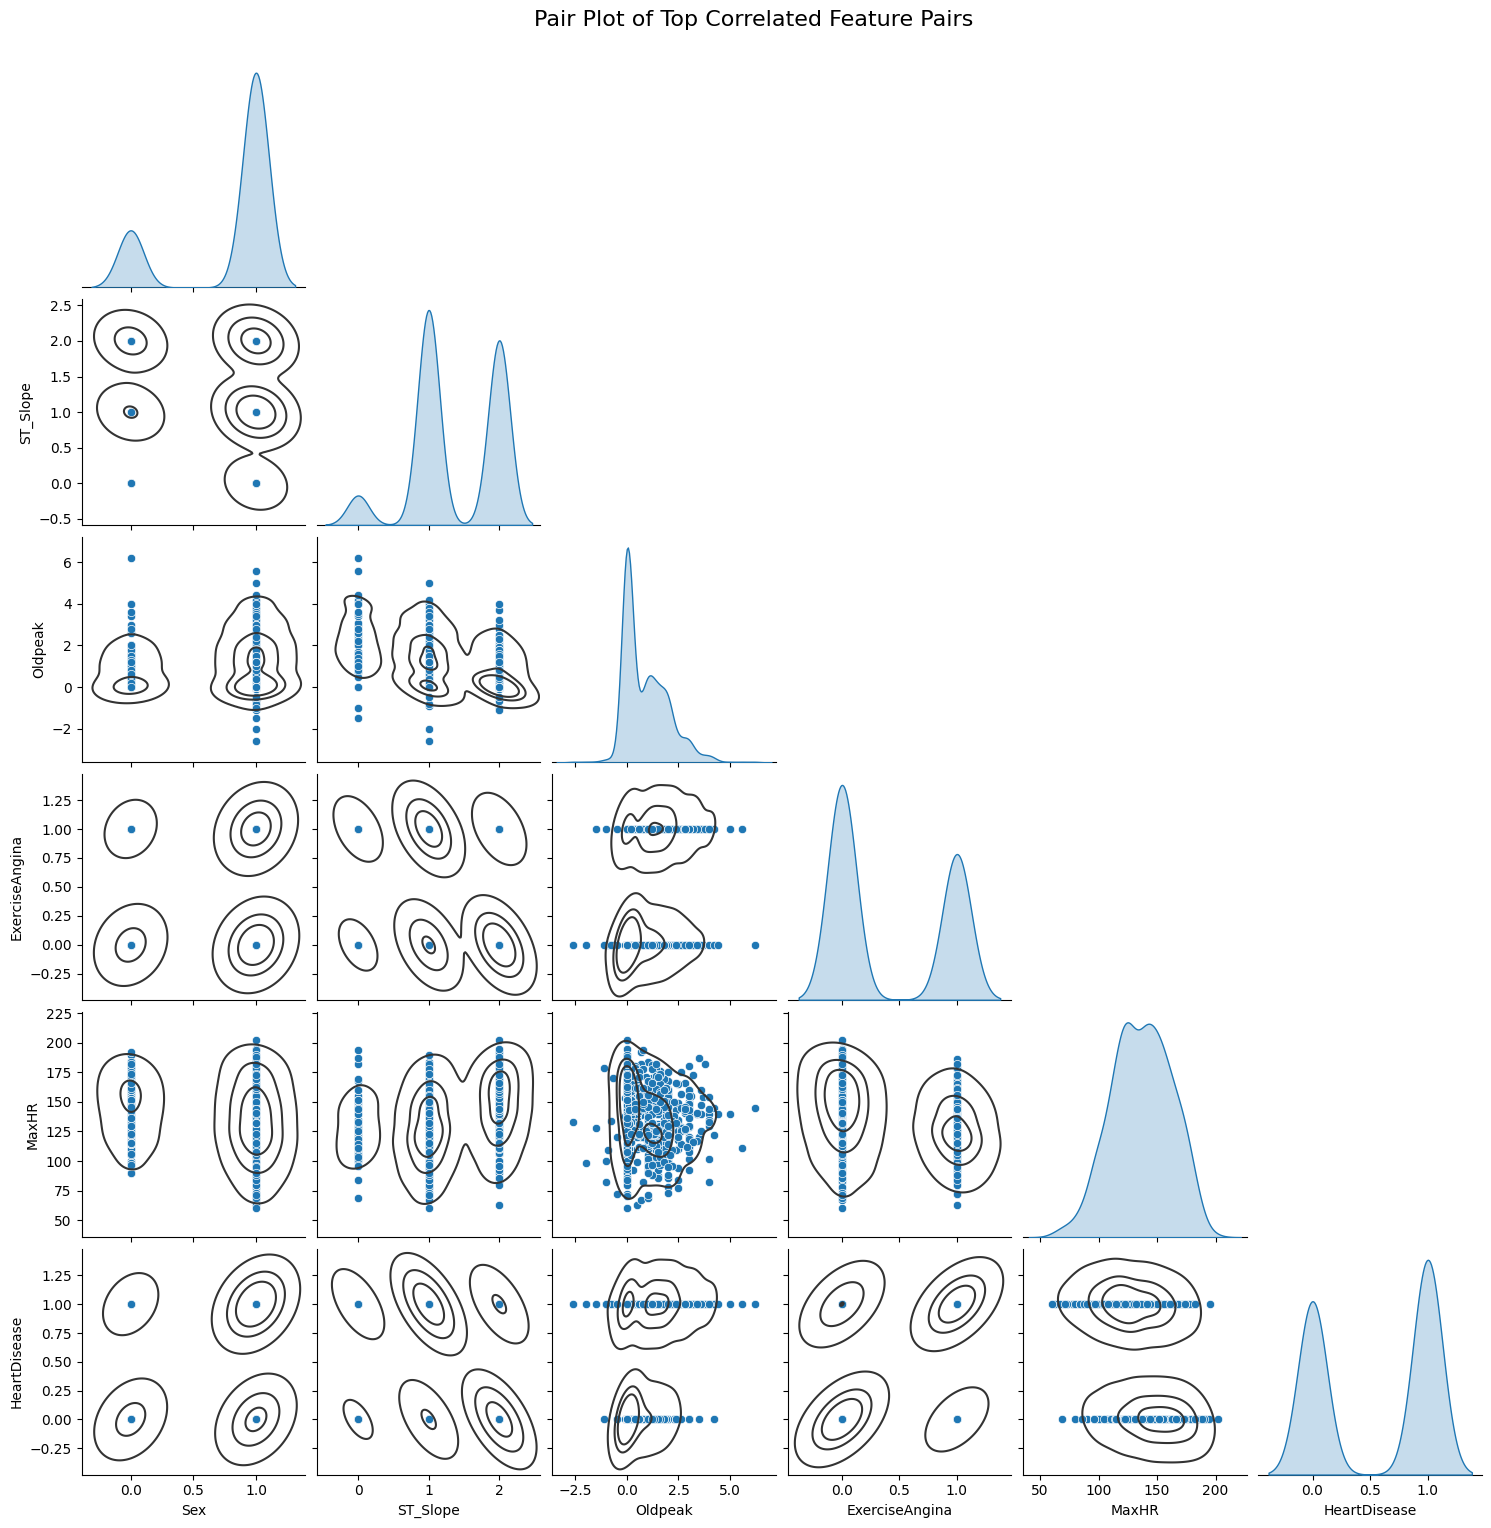

In [11]:
# --- Step 1: Compute correlation ---
corr = df_encoded.select_dtypes(include=['float64', 'int64', 'int32']).corr()

# --- Step 2: Find top N correlated pairs (excluding self-correlation) ---
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))  # upper triangle only
    .stack()
    .sort_values(ascending=False)
)

top_n = 5  # number of pairs
print("Top correlated feature pairs:\n", corr_pairs.head(top_n))

# --- Step 3: Extract unique feature names from these pairs ---
top_features = list(set([col for pair in corr_pairs.head(top_n).index for col in pair]))
print("Selected features for pairplot:", top_features)

# --- Step 4: Pairplot ---
g = sns.pairplot(df_encoded[top_features], diag_kind="kde", corner=True)
g.map_lower(sns.kdeplot, levels=4, color=".2")
plt.suptitle('Pair Plot of Top Correlated Feature Pairs', y=1.02, fontsize=16)
plt.show()

# **3. Verifikasi Kualitas Data**

In [12]:
# 1️⃣ Fungsi untuk memeriksa konsistensi data
def check_data_consistency(df):
    """
    Memeriksa konsistensi data:
    - Tipe data tiap kolom
    - Proporsi missing value
    - Unik nilai tiap kolom (untuk kolom object)

    Returns: dictionary summary
    """
    consistency_report = {}

    for col in df.columns:
        consistency_report[col] = {
            'dtype': df[col].dtype,
            'missing_count': df[col].isnull().sum(),
            'missing_percent': round(df[col].isnull().mean() * 100, 2)
        }
        if df[col].dtype == 'object':
            consistency_report[col]['unique_values'] = df[col].nunique()

    return consistency_report


# 2️⃣ Fungsi untuk mendeteksi dan menangani duplikat
def detect_and_handle_duplicates(df, drop_duplicates=False):
    """
    Mendeteksi duplikat di DataFrame.
    Jika drop_duplicates=True, fungsi akan menghapus duplikat dan mengembalikan DataFrame baru.

    Returns:
        duplicate_report: dict dengan jumlah total duplikat
        df_cleaned: DataFrame baru tanpa duplikat jika drop_duplicates=True
    """
    duplicate_count = df.duplicated().sum()
    duplicate_report = {'total_duplicates': duplicate_count}

    if drop_duplicates:
        df_cleaned = df.drop_duplicates()
        return duplicate_report, df_cleaned
    else:
        return duplicate_report, df.copy()


# 3️⃣ Fungsi untuk memeriksa apakah nilai dalam kolom berada dalam rentang wajar
def check_value_ranges(df, column_ranges):
    """
    Memeriksa apakah nilai dalam kolom tertentu berada dalam rentang wajar.

    Args:
        df: DataFrame
        column_ranges: dict, format {'col_name': (min_value, max_value)}

    Returns:
        range_report: dict, berisi jumlah nilai yang berada di luar rentang untuk tiap kolom
    """
    range_report = {}

    for col, (min_val, max_val) in column_ranges.items():
        if col in df.columns:
            out_of_range = df[(df[col] < min_val) | (df[col] > max_val)]
            range_report[col] = {
                'out_of_range_count': len(out_of_range),
                'total_count': len(df),
                'percentage': round(len(out_of_range)/len(df) * 100, 2)
            }
        else:
            range_report[col] = 'Column not found'

    return range_report

In [13]:
from pprint import pprint

# 1. Cek konsistensi
consistency = check_data_consistency(df)
pprint(consistency)

# 2. Deteksi duplikat
duplicates, df_no_dup = detect_and_handle_duplicates(df, drop_duplicates=True)
pprint(duplicates)

# 3. Cek rentang nilai
column_ranges = {'Age': (30, 65)}
range_report = check_value_ranges(df, column_ranges)
pprint(range_report)

{'Age': {'dtype': dtype('int64'),
         'missing_count': np.int64(0),
         'missing_percent': np.float64(0.0)},
 'ChestPainType': {'dtype': dtype('O'),
                   'missing_count': np.int64(0),
                   'missing_percent': np.float64(0.0),
                   'unique_values': 4},
 'Cholesterol': {'dtype': dtype('int64'),
                 'missing_count': np.int64(0),
                 'missing_percent': np.float64(0.0)},
 'ExerciseAngina': {'dtype': dtype('O'),
                    'missing_count': np.int64(0),
                    'missing_percent': np.float64(0.0),
                    'unique_values': 2},
 'FastingBS': {'dtype': dtype('int64'),
               'missing_count': np.int64(0),
               'missing_percent': np.float64(0.0)},
 'HeartDisease': {'dtype': dtype('int64'),
                  'missing_count': np.int64(0),
                  'missing_percent': np.float64(0.0)},
 'MaxHR': {'dtype': dtype('int64'),
           'missing_count': np.int64(0),
      